#Instalación de librerias

In [ ]:
%pip install pandas
%pip install numpy
%pip install duckdb
%pip install seaborn
%pip install matplotlib
%pip install scipy
%pip install scikit-posthocs

#Importación de librerias necesarias y carga de la base de datos

In [2]:
###Importamos las librerías necesarias
import pandas as pd

import numpy as np

import duckdb

import seaborn as sns

import matplotlib.pyplot as plt

import scipy.stats as stats


In [ ]:
#df_sismos=pd.read_csv(r"C:\Users\Asus\Desktop\Maestría UCentral\Analitica de Datos\Primer Semestre\Programación para analítica de datos\Taller 5\Sismos2.csv", sep=';', decimal=',')
#df_sismos

df_sismos = pd.read_csv("Sismos2.csv",sep=";",decimal=",")
df_sismos


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,depthError,magError,magNst,status,locationSource,magSource,Details,City,state,Place
0,19/08/2026 5:07,60705,-774357,10.00,4.4,mb,41.0,137,19,7,...,1913,103,27,reviewed,us,us,17 km SSW of Bahía Solano,Bahía Solano,Choco,Colombia
1,15/08/2026 19:18,68902,-730936,146.65,4.2,mb,29.0,118,991,77,...,9958,132,16,reviewed,us,us,11 km SSW of Piedecuesta,Piedecuesta,Santander,Colombia
2,13/08/2026 9:42,48666,-763547,105.62,4.3,mb,34.0,101,1551,108,...,9711,153,12,reviewed,us,us,13 km WSW of San José del Palmar,San José del Palmar,Choco,Colombia
3,11/08/2026 17:29,62416,-737019,116.73,4.5,mb,26.0,61,706,84,...,7293,191,8,reviewed,us,us,12 km ENE of Landázuri,Landázuri,Santander,Colombia
4,11/08/2026 10:43,49201,-763385,100.61,4.2,mb,34.0,113,1498,57,...,8754,112,23,reviewed,us,us,11 km WNW of San José del Palmar,San José del Palmar,Choco,Colombia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
637,30/01/2020 1:33,67813,-729965,162.56,4.6,mb,NaN,46,2331,1,...,89,59,84,reviewed,us,us,3 km NW of Cepitá,Cepitá,Santander,Colombia
638,16/01/2020 23:32,22118,-796665,10.00,4.8,mb,NaN,136,2307,108,...,18,4,199,reviewed,us,us,107 km WNW of Tumaco,Tumaco,Nariño,Colombia
639,14/01/2020 12:57,68007,-730241,157.09,4.8,mb,NaN,49,2332,84,...,54,29,362,reviewed,us,us,7 km NW of Cepitá,Cepitá,Santander,Colombia
640,12/01/2020 18:31,67526,-730103,158.18,4.5,mb,NaN,42,23,126,...,39,78,48,reviewed,us,us,3 km W of Cepitá,Cepitá,Santander,Colombia


#Exploración inicial de la base de datos

In [4]:
df_sismos.info()

<class 'pandas.DataFrame'>
RangeIndex: 642 entries, 0 to 641
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             642 non-null    str    
 1   latitude         642 non-null    int64  
 2   longitude        642 non-null    int64  
 3   depth            642 non-null    float64
 4   mag              642 non-null    float64
 5   magType          642 non-null    str    
 6   nst              408 non-null    float64
 7   gap              642 non-null    int64  
 8   dmin             642 non-null    int64  
 9   rms              642 non-null    int64  
 10  net              642 non-null    str    
 11  id               642 non-null    str    
 12  updated          642 non-null    str    
 13  type             642 non-null    str    
 14  horizontalError  642 non-null    int64  
 15  depthError       642 non-null    int64  
 16  magError         642 non-null    int64  
 17  magNst           642 non-nu

In [5]:
print((df_sismos.isna().mean() * 100).round(1).to_string())

time                0.0
latitude            0.0
longitude           0.0
depth               0.0
mag                 0.0
magType             0.0
nst                36.4
gap                 0.0
dmin                0.0
rms                 0.0
net                 0.0
id                  0.0
updated             0.0
type                0.0
horizontalError     0.0
depthError          0.0
magError            0.0
magNst              0.0
status              0.0
locationSource      0.0
magSource           0.0
Details             0.0
City                0.3
state               0.0
Place               0.0


In [7]:
print('\nDepartamentos:', df_sismos['state'].unique())


Departamentos: <StringArray>
[             'Choco',          'Santander',              'Sucre',
           'Casanare',       'Cundinamarca',    'Valle del Cauca',
          'Antioquia',             'Boyaca', 'Norte de Santander',
              'Huila',            'Bolivar',         'La Guajira',
              'Cauca',             'Nariño',             'Tolima',
            'Quindio',          'Magdalena',              'Zulia',
              'Apure',            'Cordoba',               'Meta',
             'Arauca',           'Monteria',              'Cesar',
             'CARCHI',          'Risaralda',             'Vaupes']
Length: 27, dtype: str


#Limpieza y validación de los datos

In [8]:
#1. Normalización de datos geográficos
Coordenadas=['latitude', 'longitude']
for col in Coordenadas:
    df_sismos[col] = df_sismos[col].astype(str).str.replace(',', '', regex=False).astype(float)

Coordenadas=['latitude', 'longitude']
df_sismos[Coordenadas]=df_sismos[Coordenadas]/10000

#2. Conversión de tipos de variables
df_sismos['depth'] = pd.to_numeric(df_sismos['depth'], errors='coerce')

df_sismos['mag'] = pd.to_numeric(df_sismos['mag'], errors='coerce')

df_sismos['Details'] = df_sismos['Details'].str.strip()

#3. Relleno de registros en blanco a partir de otras variables
City_na = df_sismos['City'].isna()
df_sismos.loc[City_na, 'City'] = df_sismos.loc[City_na, 'Details']

#4. Clasificación del nivel de profundidad (SGC, 2023)
df_sismos['Nivel_profundidad'] = np.where(
    df_sismos['depth'] <= 30.0,
    "Terremotos superficiales",
    np.where(
        df_sismos['depth'] <= 120.0,
        'Terremotos intermedios',
        'Terremotos profundos'
    )
)

#5. Clasificación de la magnitud (Richter & Gutemberg, 1935)
df_sismos['Clasificacion_Magnitud'] = np.where(
    df_sismos['mag'] <=2.9,
    'Micro',
    np.where(
        (df_sismos['mag'] >=3.0) & (df_sismos['mag'] <= 3.9),
        'Menor',
        np.where(
            (df_sismos['mag'] >=4.0) & (df_sismos['mag'] <= 4.9),
            'Ligero',
            np.where(
                (df_sismos['mag'] >=5.0) & (df_sismos['mag'] <= 5.9),
                'Moderado',
                np.where(
                    (df_sismos['mag'] >=6.0) & (df_sismos['mag'] <= 6.9),
                    'Fuerte',
                    np.where(
                        (df_sismos['mag'] >=7.0) & (df_sismos['mag'] <= 7.9),
                        'Muy fuerte',
                        'Grave'
                    )
                )
            )
        )
    )
)

#6. Clasificación de la amenaza sísmica teniendo en cuenta el departamento
df_sismos['state'] = df_sismos['state'].str.lower()

df_sismos['state'] = df_sismos['state'].replace('carchi', 'carchi-nariño colombia-ecuador border region')
df_sismos['state'] = df_sismos['state'].replace('zulia', 'zulia-atlantico colombia-venezuela border region')
df_sismos['state'] = df_sismos['state'].replace('apure', 'apure-santander colombia-venezuela border region')

estados_alto = [
    "nariño", "quindio", "norte de santander", "huila", "cauca", 
    "risaralda", "carchi-nariño colombia-ecuador border region", 
    "choco", "santander", "valle del cauca", 
    "tolima", "zulia-atlantico colombia-venezuela border region", 
    "panama-colombia border region", 
    "colombia-ecuador border region"
]

estados_intermedio = [
    "cundinamarca", "magdalena", "cordoba", "bolivar", "la guajira", 
    "cesar", "antioquia", "boyaca", "near the north coast of colombia", 
    "monteria"
]

estados_bajo = [
    "casanare", "apure-santander colombia-venezuela border region", "meta", "vaupes", "sucre", "arauca"
]

condiciones = [
    df_sismos['state'].isin(estados_alto),
    df_sismos['state'].isin(estados_intermedio),
    df_sismos['state'].isin(estados_bajo)
]

resultados = ["Alto", "Intermedio", "Bajo"]

df_sismos['Hazard_level'] = np.select(condiciones, resultados, default=None)

#7. Calculo de la intensidad máxima (karnik, 1969 & Salcedo-Hurtado et al., 2023)
a=2
b=2
c=0.7

df_sismos['Intensidad_maxima']=a*df_sismos['mag']-b*np.log10(df_sismos['depth'])-c #(Teniendo la ecuación empírica de Karnik,1969; se despeja la Intensidad máxima)

#8. Renombre de columnas
df_sismos = df_sismos.rename(columns={
    'time':'Fecha_evento',
    'latitude':'Latitud',
    'longitude':'Longitud',
    'mag' : 'Magnitud',
    'depth':'Profundidad',
    'nst': 'Estaciones_sismicas',
    'gap': 'Area_no_estaciones',
    'dmin': 'Distancia_epicentro',
    'rms': 'Eror_tiempo_arrivo',
    'horizontalError' : 'Error_distancia',
    'magError' : 'Error_magnitud',
    'magNst' : 'Estaciones_sismicas_Mag',
    'Details': 'Detalles_evento',
    'City': 'Ciudad',
    'state': 'Departamento',
    'Place': 'Pais',
    'Hazard_level' : 'Nivel_amenaza'
})

#9. Eliminación de variables

columnas_eliminar = [ 
    'net', 'status', 'locationSource', 'magSource'
]

df_sismos = df_sismos.drop(columns=columnas_eliminar)


In [9]:
# 10. Verficación de calidad de datos
print("\nFilas duplicadas:", df_sismos.duplicated().sum())

print('\nDepartamentos:', df_sismos['Departamento'].unique())

print('\nMunicipios:', df_sismos['Ciudad'].unique())




Filas duplicadas: 0

Departamentos: <StringArray>
[                                           'choco',
                                        'santander',
                                            'sucre',
                                         'casanare',
                                     'cundinamarca',
                                  'valle del cauca',
                                        'antioquia',
                                           'boyaca',
                               'norte de santander',
                                            'huila',
                                          'bolivar',
                                       'la guajira',
                                            'cauca',
                                           'nariño',
                                           'tolima',
                                          'quindio',
                                        'magdalena',
 'zulia-atlantico colombia-venezuela border regi

In [10]:
print((df_sismos.isna().mean() * 100).round(1).to_string())

Fecha_evento                0.0
Latitud                     0.0
Longitud                    0.0
Profundidad                 0.0
Magnitud                    0.0
magType                     0.0
Estaciones_sismicas        36.4
Area_no_estaciones          0.0
Distancia_epicentro         0.0
Eror_tiempo_arrivo          0.0
id                          0.0
updated                     0.0
type                        0.0
Error_distancia             0.0
depthError                  0.0
Error_magnitud              0.0
Estaciones_sismicas_Mag     0.0
Detalles_evento             0.0
Ciudad                      0.0
Departamento                0.0
Pais                        0.0
Nivel_profundidad           0.0
Clasificacion_Magnitud      0.0
Nivel_amenaza               0.0
Intensidad_maxima           0.0


#Consultas en base de datos

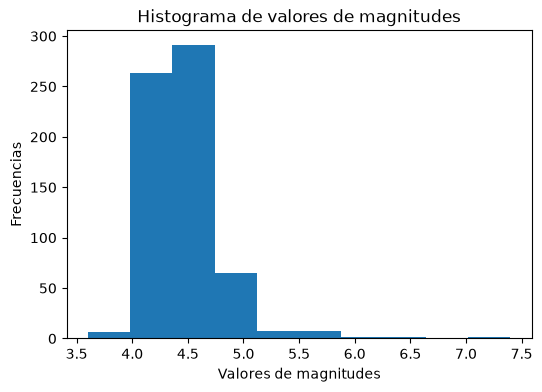

In [11]:
plt.figure(figsize=(6,4))

plt.hist(df_sismos['Magnitud'])
plt.title('Histograma de valores de magnitudes')
plt.xlabel('Valores de magnitudes')
plt.ylabel('Frecuencias')

plt.show()

In [12]:
#1. La consulta 1 muestra todos los eventos sísmicos con magnitudes entre 4 y 4.9, intensidades entre 4 y 6, niveles de amenaza intermedios a altos
Consulta1="""
SELECT *
FROM df_sismos
WHERE Magnitud BETWEEN 4.0 AND 4.9
AND Intensidad_maxima BETWEEN 4 AND 6
AND Nivel_amenaza IN ('Intermedio', 'Alto')
"""

df_Consulta1=duckdb.query(Consulta1).to_df
df_Consulta1()

,Fecha_evento,Latitud,Longitud,Profundidad,Magnitud,magType,Estaciones_sismicas,Area_no_estaciones,Distancia_epicentro,Eror_tiempo_arrivo,...,Error_magnitud,Estaciones_sismicas_Mag,Detalles_evento,Ciudad,Departamento,Pais,Nivel_profundidad,Clasificacion_Magnitud,Nivel_amenaza,Intensidad_maxima
0,11/08/2026 17:29,6.2416,-73.7019,116.73,4.5,mb,26.0,61,706,84,...,191,8,12 km ENE of Landázuri,Landázuri,santander,Colombia,Terremotos intermedios,Ligero,Alto,4.165635
1,2/08/2026 12:12,7.6498,-77.1911,34.42,4.4,mb,35.0,95,145,44,...,139,15,24 km NNW of Riosucio,Riosucio,choco,Colombia,Terremotos intermedios,Ligero,Alto,5.026378
2,19/07/2026 20:44,6.7762,-73.0623,153.07,4.6,mb,55.0,45,878,8,...,32,291,6 km NE of Jordán,Jordán,santander,Colombia,Terremotos profundos,Ligero,Alto,4.130220
3,28/06/2026 3:39,5.1217,-76.2727,96.89,4.4,mb,44.0,115,463,77,...,7,58,25 km N of San José del Palmar,San José del Palmar,choco,Colombia,Terremotos intermedios,Ligero,Alto,4.127442
4,26/06/2026 3:31,4.0074,-76.5596,10.00,4.2,mb,25.0,111,3492,102,...,124,18,11 km NW of Darien,Darien,valle del cauca,Colombia,Terremotos superficiales,Ligero,Alto,5.700000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,28/03/2020 0:55,6.7999,-73.0549,155.01,4.9,mb,NaN,75,2315,122,...,77,53,8 km NNE of Jordán,Jordán,santander,Colombia,Terremotos profundos,Ligero,Alto,4.719281
182,5/03/2020 21:38,6.7766,-72.9332,160.52,4.6,mb,NaN,38,2364,136,...,98,31,5 km ENE of Cepitá,Cepitá,santander,Colombia,Terremotos profundos,Ligero,Alto,4.088942
183,29/02/2020 6:18,5.8029,-77.6217,10.00,4.3,mb,NaN,106,3421,121,...,188,8,40 km WNW of Nuquí,Nuquí,choco,Colombia,Terremotos superficiales,Ligero,Alto,5.900000
184,30/01/2020 1:33,6.7813,-72.9965,162.56,4.6,mb,NaN,46,2331,1,...,59,84,3 km NW of Cepitá,Cepitá,santander,Colombia,Terremotos profundos,Ligero,Alto,4.077973


In [13]:
#2. La consulta 2 muestra el conteo de cada uno de los eventos sísmicos por departamento
Consulta2 ="""
SELECT Departamento,
COUNT(Departamento) AS Conteo
FROM df_sismos
WHERE Magnitud BETWEEN 4.0 AND 4.9
AND Intensidad_maxima BETWEEN 4 AND 6
AND Nivel_amenaza IN ('Intermedio', 'Alto')
GROUP BY Departamento
ORDER BY Conteo DESC
"""
df_Consulta2=duckdb.query(Consulta2).to_df
df_Consulta2()

,Departamento,Conteo
0,santander,54
1,choco,44
2,antioquia,28
3,valle del cauca,15
4,nariño,9
5,cundinamarca,9
6,cauca,6
7,magdalena,3
8,norte de santander,3
9,huila,3


In [14]:
#3. La consulta 3 Muestra los departamentos con mayor cantidad de eventos sísmicos, utiles para la prueba de hipótesis
Consulta3="""
SELECT Departamento,
Conteo
FROM(SELECT Departamento,
COUNT(Departamento) AS Conteo
FROM df_sismos
WHERE Magnitud BETWEEN 4.0 AND 4.9
AND Intensidad_maxima BETWEEN 4 AND 6
AND Nivel_amenaza IN ('Intermedio', 'Alto')
GROUP BY Departamento)
WHERE Conteo > 10
ORDER BY Conteo DESC
"""
df_Consulta3=duckdb.query(Consulta3).to_df
df_Consulta3()

,Departamento,Conteo
0,santander,54
1,choco,44
2,antioquia,28
3,valle del cauca,15


#Prueba de hipótesis Chi-cuadrado

In [15]:
#Prueba de hipotesis Distribución Chi-Cuadrado:
#Es ideal para comparar lo que se observa en el mundo real con lo que se esperaría encontrar teóricamente
#La distribución trabaja con conteos y frecuencias

df_Consulta3 = duckdb.query(Consulta3).to_df()

# Mostrar la tabla descriptiva que te da SQL
print("--- DATOS OBSERVADOS (DESDE SQL) ---")
print(df_Consulta3)
print("------------------------------------\n")

# 2. Extraer la serie de conteos para la prueba de hipótesis
# Chi-cuadrado necesita únicamente la lista de números (las frecuencias observadas)
frecuencias_observadas = df_Consulta3['Conteo']

# 3. Ejecutar la prueba de Chi-cuadrado de Bondad de Ajuste
# Automáticamente asume que la hipótesis nula es una distribución equitativa
chi2_stat, p_val_chi = stats.chisquare(frecuencias_observadas)

print("--- PRUEBA DE HIPÓTESIS (CHI-CUADRADO) ---")
print(f"Estadístico Chi2: {chi2_stat:.4f}")
print(f"Valor p: {p_val_chi:.4e}" if p_val_chi < 0.001 else f"Valor p: {p_val_chi:.4f}")
print("------------------------------------------\n")
#Ho: los eventos sísmicos de distribuyen de forma equitativa entre los departamentos, para este caso sería #total de sismos/#departamentos (141/4) ~ 35 sismos por departamento
#Hi: Los eventos sísmicos no se distribuyen de forma equitativa entre los departamentos
# 4. Conclusión científica automática
if p_val_chi < 0.05:
    depto_max = df_Consulta3.iloc[0]['Departamento'].upper()
    conteo_max = df_Consulta3.iloc[0]['Conteo']
    print(f"CONCLUSIÓN: Se rechaza la hipótesis nula (p < 0.05).")
    print(f"La recurrencia NO es uniforme. El departamento con mayor recurrencia ")
    print(f"estadísticamente significativa es {depto_max} con {conteo_max} eventos sismos.")
else:
    print("CONCLUSIÓN: No se rechaza la hipótesis nula (p >= 0.05).")
    print("Los sismos se distribuyen de forma equitativa; no hay un líder claro en recurrencia.")

#La Distribución Chi-Cuadrado lo que hace es calcular una discrepancia de cada uno de los registros mediante la formula
#Sumatoria[(Observado-Esperado)^2/Esperado]
#el valor de Esperado es de ~ 35 eventos sísmicos por departamento y los valores observados son los que aparecen en la consulta SQL

--- DATOS OBSERVADOS (DESDE SQL) ---
      Departamento  Conteo
0        santander      54
1            choco      44
2        antioquia      28
3  valle del cauca      15
------------------------------------

--- PRUEBA DE HIPÓTESIS (CHI-CUADRADO) ---
Estadístico Chi2: 25.2695
Valor p: 1.3561e-05
------------------------------------------

CONCLUSIÓN: Se rechaza la hipótesis nula (p < 0.05).
La recurrencia NO es uniforme. El departamento con mayor recurrencia 
estadísticamente significativa es SANTANDER con 54 eventos sismos.


In [18]:
Consulta_4="""
SELECT Departamento, 
Intensidad_maxima,
Magnitud
FROM df_sismos
WHERE Magnitud BETWEEN 4.0 AND 4.9
AND Intensidad_maxima BETWEEN 4 AND 6
AND Nivel_amenaza IN ('Intermedio', 'Alto')
AND Departamento IN ('santander', 'choco', 'antioquia', 'valle del cauca')
"""
df_Consulta_4=duckdb.query(Consulta_4).to_df
df_Consulta_4()

,Departamento,Intensidad_maxima,Magnitud
0,santander,4.165635,4.5
1,choco,5.026378,4.4
2,santander,4.130220,4.6
3,choco,4.127442,4.4
4,valle del cauca,5.700000,4.2
...,...,...,...
136,santander,4.719281,4.9
137,santander,4.088942,4.6
138,choco,5.900000,4.3
139,santander,4.077973,4.6


#Gráficos de boxplot respecto a intensidades y magnitudes

C:\Users\Asus\AppData\Local\Temp\ipykernel_10448\197574983.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Departamento', y='Intensidad_maxima', data=df_Consulta_4, palette='Set2')


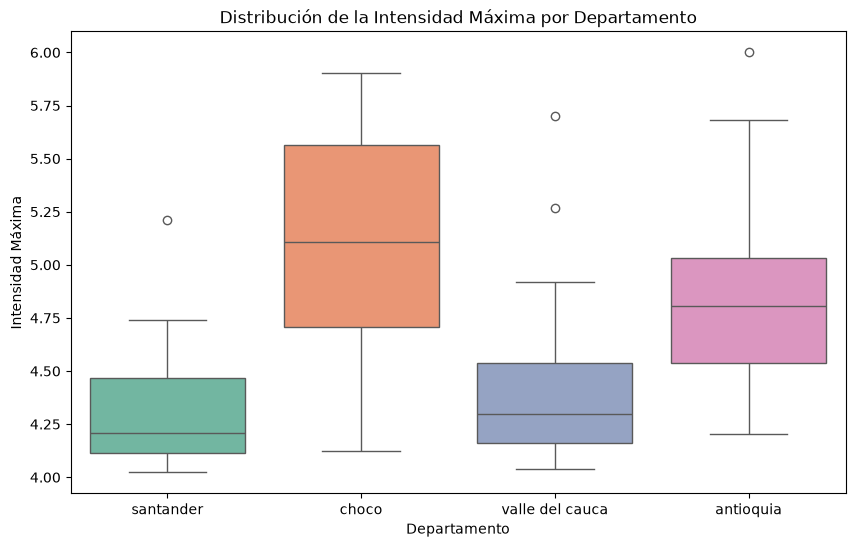

In [22]:
df_Consulta_4 = duckdb.query(Consulta_4).to_df()

plt.figure(figsize=(10, 6))
sns.boxplot(x='Departamento', y='Intensidad_maxima', data=df_Consulta_4, palette='Set2')
plt.title('Distribución de la Intensidad Máxima por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Intensidad Máxima')
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_10448\2206920745.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Departamento', y='Magnitud', data=df_Consulta_4, palette='Set2')


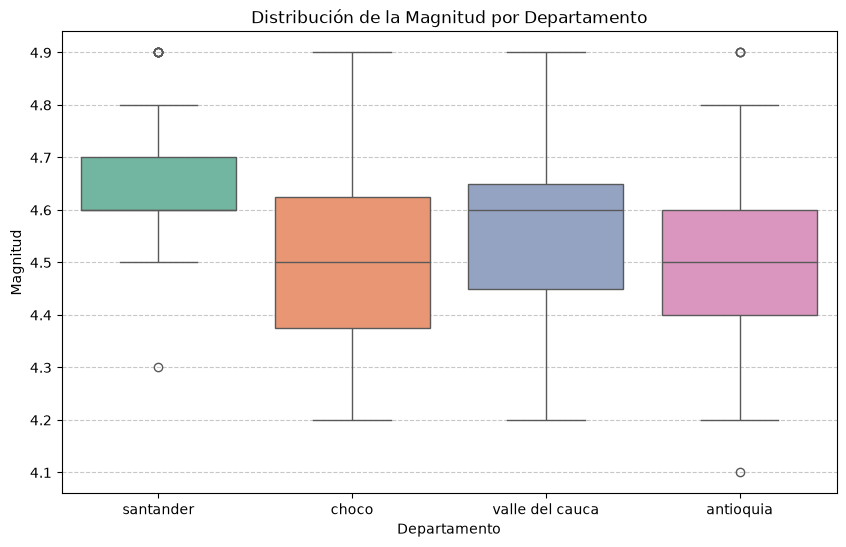

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Departamento', y='Magnitud', data=df_Consulta_4, palette='Set2')
plt.title('Distribución de la Magnitud por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Magnitud')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#Limitaciones:
#El analisis solo concentra unos valores de magnitud, intensidad y nivel de amenaza, lo que podría llegar a sesgar el resultado
#El alcance temporal es muy bajo (6años)
